<a href="https://colab.research.google.com/github/Samson-Mathai/EDUCATION-INTELLIGENCE-SYSTEM/blob/main/EDUCATION_INTELLICENCE_SYSTEM_SOURCECODE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  Student_ID            Name      Phone_No                   Email  \
0   STU-0001   Amina Ochieng  254737622679  aochieng15@example.com   
1   STU-0002  Victor Anyango  254742921822  vanyango92@example.com   
2   STU-0003     Sarah Mutua  254787786253    smutua91@example.com   
3   STU-0004   Amina Kariuki  254769623470  akariuki16@example.com   
4   STU-0005   Dennis Ndungu  254721361254   dndungu57@example.com   

     Source_From      Referred_By  Marital Status  Application mode  \
0   Social Media              NaN               1                17   
1       Referral  Samuel Kipkorir               1                15   
2          Event              NaN               1                 1   
3  Search Engine              NaN               1                17   
4   Social Media              NaN               2                39   

   Application order  C

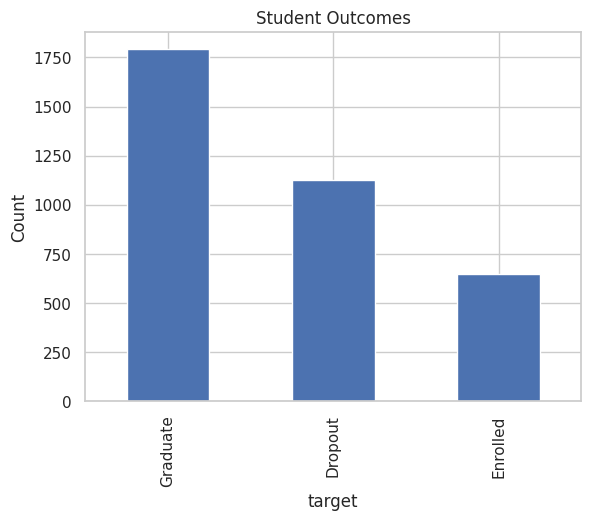

target  Dropout  Enrolled  Graduate
Course                             
33            6         2         1
171          63        29        80
8014         58        19        99
9003         68        28        74
9070         42        33       107
9085         67        58       132
9119         74        54         9
9130         65        19        34
9147        103        89       121
9238         43        30       197
9254         84        30        91
9500         94        86       446
9556         28        11        30
9670         76        41       107
9773         78        29       152
9853         69        41        48
9991        106        47        63
Course
33      66.666667
9130    55.084746
9119    54.014599
9991    49.074074
9853    43.670886
9254    40.975610
9556    40.579710
9003    40.000000
171     36.627907
9670    33.928571
8014    32.954545
9147    32.907348
9773    30.115830
9085    26.070039
9070    23.076923
9238    15.925926
9500    15.015974
Nam

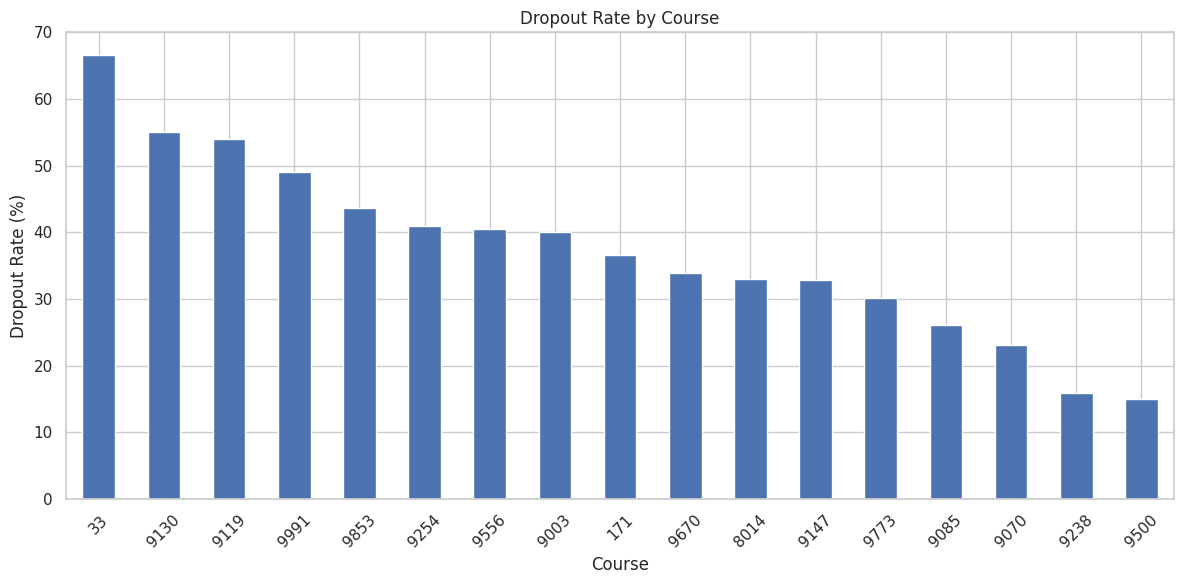

Top  Courses with Highest Dropout Rates (%):
Course
33      66.666667
9130    55.084746
9119    54.014599
9991    49.074074
9853    43.670886
Name: target, dtype: float64 

FULL YEAR ENGAGEMENT ANALYSIS 
Average Academic Evaluations Attended by Learner Status:
------------------------------------------------------------
          1st Semester (Avg)  2nd Semester (Avg)  Whole Year Total (Avg)
target                                                                  
Dropout                  7.7                 7.1                    14.7
Enrolled                 9.4                 9.4                    18.7
Graduate                 8.2                 8.1                    16.3
------------------------------------------------------------ 

COMPREHENSIVE FINANCIAL AND TUITION ANALYSIS
1. Outcomes based on Current Tuition Status (%):
target           Dropout  Enrolled  Graduate
Unpaid/Behind       86.3       8.5       5.2
Paid Up to Date     24.2      19.4      56.4 

2. Outcomes based o

/tmp/ipykernel_1779/1287350190.py:257: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_dropout.index, y=age_dropout.values, ax=axes[0, 1], palette="Reds_d")
/tmp/ipykernel_1779/1287350190.py:271: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=financial_dropout.index, x=financial_dropout.values, ax=axes[1, 1], palette="OrRd_r")


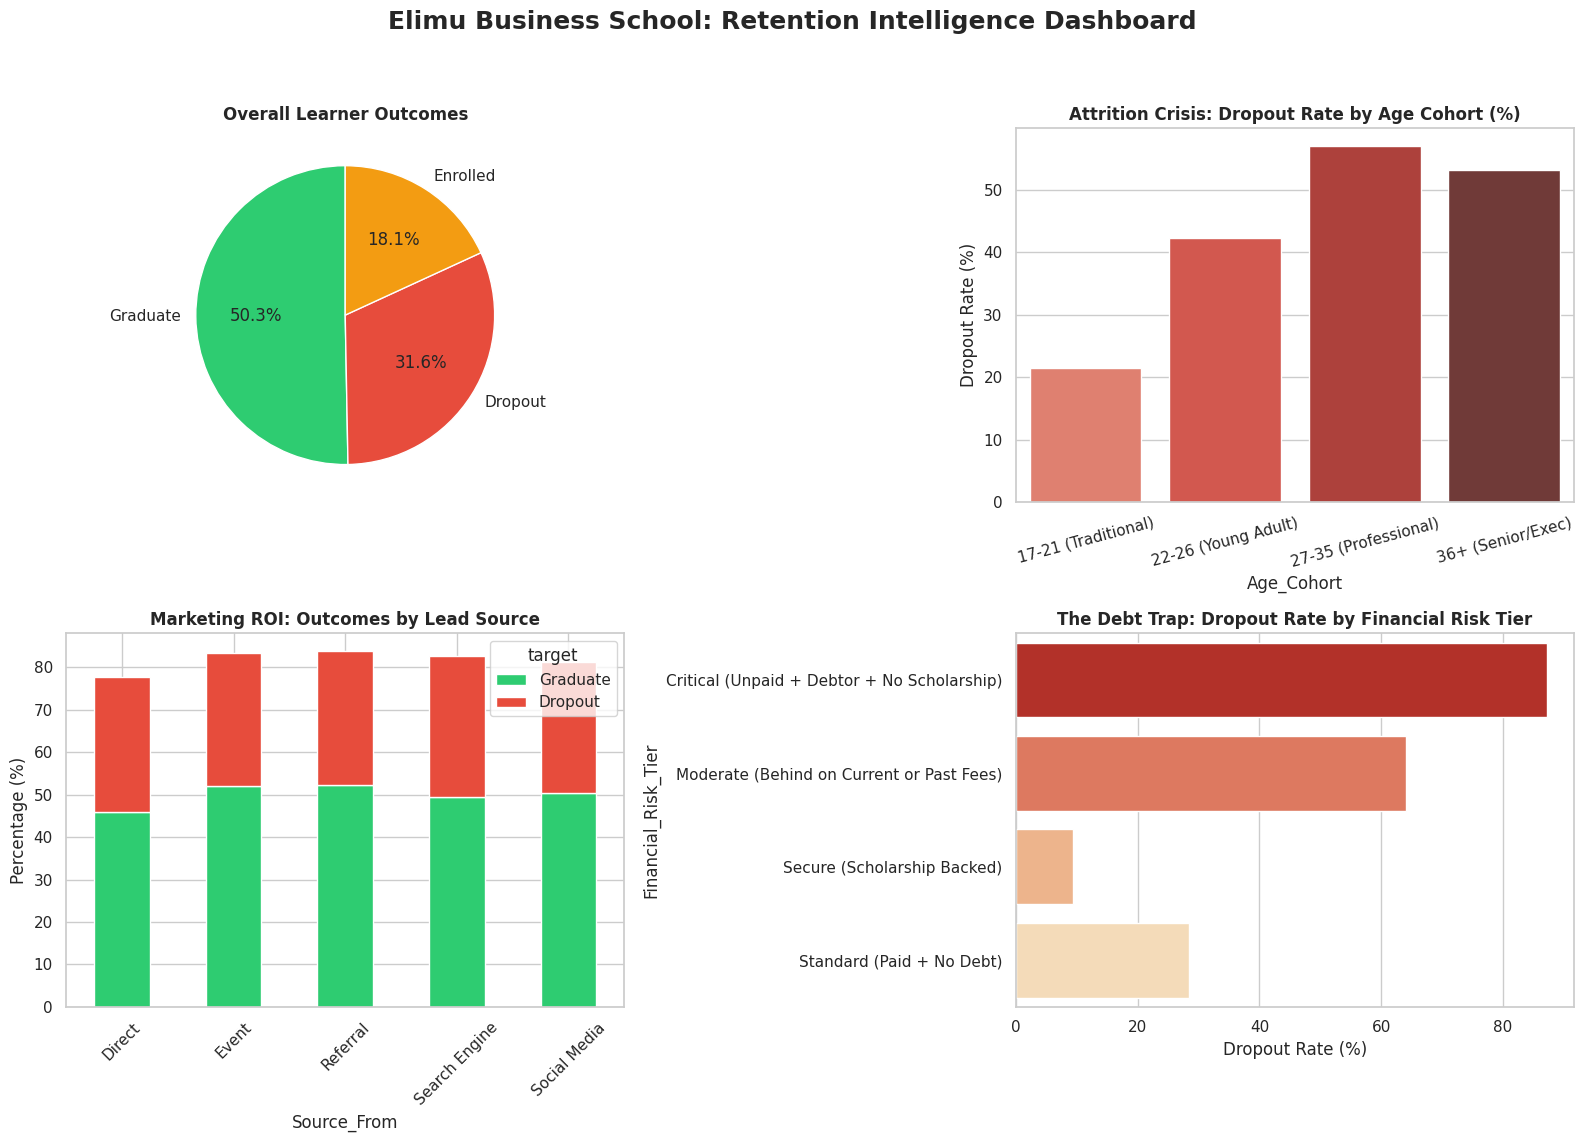

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Master Dataset downloaded


In [7]:
from google.colab import drive
drive.mount("/content/drive")
#import necessary libraries
import pandas as pd
import numpy as np

#load datasets
raw_leads = pd.read_csv('/content/drive/MyDrive/new edu int system/elimu_leads_scoring_kenya_linked.csv')
raw_students = pd.read_csv('/content/drive/MyDrive/new edu int system/students_with_dummy_pii.csv')

#Drop duplicates from both datasets to ensure a 1 to 1 merge.
leads = raw_leads.drop_duplicates(subset=['Applicant_ID'], keep='last')
students = raw_students.drop_duplicates(subset=['Student_ID'], keep='last')


#check the data
print(students.head())
print(leads.head())

students.info()
students.describe()
students.isnull().sum()

leads.info()
leads.describe()
leads.isnull().sum()

 #merge datasets to obtain a master dataframe
master_df = pd.merge(
    leads,
    students,
    left_on='Applicant_ID',
    right_on='Student_ID',
    how='inner'
)

print(master_df.shape)
print(master_df.info())
print(master_df.head())

print(master_df.isnull().sum())

master_df.to_csv(
    'master_dataset.csv',
    index=False
)

#analyze dropouts
print(master_df.columns)
master_df['target'].value_counts()

dropouts = (
    master_df['target']
    .value_counts()['Dropout']
)

total_students = len(master_df)

dropout_rate = (
    dropouts / total_students
) * 100

print(
    "Dropout Rate:",
    round(dropout_rate, 2),
    "%"
)
#visualize student outcomes by course
import matplotlib.pyplot as plt

master_df['target'].value_counts().plot(
    kind='bar'
)

plt.title('Student Outcomes')

plt.ylabel('Count')

plt.show()


course_dropout = pd.crosstab(
    master_df['Course'],
    master_df['target']
)

print(course_dropout)


course_dropout_rate = (
    master_df
    .groupby('Course')['target']
    .apply(
        lambda x:
        (x == 'Dropout').mean() * 100
    )
    .sort_values(ascending=False)
)

print(course_dropout_rate)

plt.figure(figsize=(12,6))

course_dropout_rate.plot(
    kind='bar'
)

plt.title('Dropout Rate by Course')

plt.xlabel('Course')

plt.ylabel('Dropout Rate (%)')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


# Calculate percentage of dropouts per course
course_dropout_rate = (
    master_df.groupby('Course')['target']
    .apply(lambda x: (x == 'Dropout').mean() * 100)
    .sort_values(ascending=False)
)
print("Top  Courses with Highest Dropout Rates (%):")
print(course_dropout_rate.head(5), "\n")


print("FULL YEAR ENGAGEMENT ANALYSIS ")

# 1. First Semester Engagement
sem1_engagement = master_df.groupby('target')['Curricular units 1st sem (evaluations)'].mean()

# 2. Second Semester Engagement
sem2_engagement = master_df.groupby('target')['Curricular units 2nd sem (evaluations)'].mean()

# 3. Whole Year Engagement
# add both semesters together to get the total annual engagement
master_df['Total_Year_Evaluations'] = (
    master_df['Curricular units 1st sem (evaluations)'] +
    master_df['Curricular units 2nd sem (evaluations)']
)
year_engagement = master_df.groupby('target')['Total_Year_Evaluations'].mean()

# 4. Combine into a clean, executive-ready summary table
engagement_summary = pd.DataFrame({
    '1st Semester (Avg)': round(sem1_engagement, 1),
    '2nd Semester (Avg)': round(sem2_engagement, 1),
    'Whole Year Total (Avg)': round(year_engagement, 1)
})

print("Average Academic Evaluations Attended by Learner Status:")
print("-" * 60)
print(engagement_summary)
print("-" * 60, "\n")

print("COMPREHENSIVE FINANCIAL AND TUITION ANALYSIS")

# 1. Baseline Tuition Impact
tuition_impact = pd.crosstab(master_df['Tuition fees up to date'], master_df['target'], normalize='index') * 100
print("1. Outcomes based on Current Tuition Status (%):")
# Renaming index : 0 = Unpaid, 1 = Paid
tuition_impact.index = ['Unpaid/Behind', 'Paid Up to Date']
print(round(tuition_impact, 1), "\n")

# 2. Historical Debtor Status Impact
debtor_impact = pd.crosstab(master_df['Debtor'], master_df['target'], normalize='index') * 100
print("2. Outcomes based on Registered Debtor Status (%):")
debtor_impact.index = ['Not a Debtor', 'Registered Debtor']
print(round(debtor_impact, 1), "\n")

# 3. The Scholarship safety net
scholarship_impact = pd.crosstab(master_df['Scholarship holder'], master_df['target'], normalize='index') * 100
print("3. Outcomes based on Scholarship Status (%):")
scholarship_impact.index = ['No Scholarship', 'Scholarship Holder']
print(round(scholarship_impact, 1), "\n")

# 4. Compounding Financial Risk
# Categorize learners into tiers based on how many financial red flags they have.
master_df['Financial_Risk_Tier'] = np.where(
    (master_df['Tuition fees up to date'] == 0) & (master_df['Debtor'] == 1) & (master_df['Scholarship holder'] == 0),
    'Critical (Unpaid + Debtor + No Scholarship)',
    np.where(
        (master_df['Tuition fees up to date'] == 0) | (master_df['Debtor'] == 1),
        'Moderate (Behind on Current or Past Fees)',
        np.where(
            master_df['Scholarship holder'] == 1,
            'Secure (Scholarship Backed)',
            'Standard (Paid + No Debt)'
        )
    )
)

financial_risk_outcomes = pd.crosstab(master_df['Financial_Risk_Tier'], master_df['target'], normalize='index') * 100

print("4. Dropout Probability by Compounding Financial Risk Tier (%):")
# Isolate just the Dropout column and sort it highest to lowest to show exactly where the danger is
print(round(financial_risk_outcomes[['Dropout']].sort_values(by='Dropout', ascending=False), 1), "\n")

print(" AGE AND DEMOGRAPHIC RETENTION ANALYSIS")

# 1. Baseline Average Age by Target
age_baseline = master_df.groupby('target')['Age at enrollment'].mean()
print("1. Average Age by Learner Status:")
print(round(age_baseline, 1), "\n")

# 2. Age Cohort/Bracket Analysis
# Grouping students into logical life stage categories
bins = [16, 21, 26, 35, 100]
labels = ['17-21 (Traditional)', '22-26 (Young Adult)', '27-35 (Professional)', '36+ (Senior/Exec)']
master_df['Age_Cohort'] = pd.cut(master_df['Age at enrollment'], bins=bins, labels=labels)

# Calculate outcome percentages across these cohorts
cohort_outcomes = pd.crosstab(master_df['Age_Cohort'], master_df['target'], normalize='index') * 100

print("2. Full Outcomes by Age Cohort (%):")
print(round(cohort_outcomes, 1), "\n")

# 3. Isolating the Highest Risk Demographics
print("3. Dropout Probability by Age Cohort:")
# Sort highest to lowest to show which demographic is struggling the most
print(round(cohort_outcomes[['Dropout']].sort_values(by='Dropout', ascending=False), 1), "\n")

source_retention = pd.crosstab(master_df['Source_From'], master_df['target'], normalize='index') * 100

    # 2. Format for readability
source_retention.index.name = 'Marketing Channel'

print("1. Learner Outcomes by Marketing Channel (%):")
print(round(source_retention, 1), "\n")

print("2. The High-Risk Marketing Channels -Sorted by Dropout Rate:")
    # Sort highest to lowest dropout rate to expose inefficient marketing spend
print(round(source_retention[['Dropout']].sort_values(by='Dropout', ascending=False), 1), "\n")

print("3. The High-Quality Marketing Channels -Sorted by Graduation Rate:")
    # Sort highest to lowest graduation rate to show where budget should be increased
print(round(source_retention[['Graduate']].sort_values(by='Graduate', ascending=False), 1), "\n")


# Retention Intelligence Dashboard
import seaborn as sns
# Set the visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Elimu Business School: Retention Intelligence Dashboard', fontsize=18, fontweight='bold', y=0.98)

# 1. Overall Outcomes
outcome_counts = master_df['target'].value_counts()
axes[0, 0].pie(outcome_counts, labels=outcome_counts.index, autopct='%1.1f%%', startangle=90, colors=['#2ecc71', '#e74c3c', '#f39c12'])
axes[0, 0].set_title('Overall Learner Outcomes', fontweight='bold')

# 2. Dropout by Age Cohort
age_dropout = master_df[master_df['target'] == 'Dropout']['Age_Cohort'].value_counts() / master_df['Age_Cohort'].value_counts() * 100
sns.barplot(x=age_dropout.index, y=age_dropout.values, ax=axes[0, 1], palette="Reds_d")
axes[0, 1].set_title('Attrition Crisis: Dropout Rate by Age Cohort (%)', fontweight='bold')
axes[0, 1].set_ylabel('Dropout Rate (%)')
axes[0, 1].tick_params(axis='x', rotation=15)

# 3. Marketing ROI: Graduation vs Dropout by Source
source_outcomes = pd.crosstab(master_df['Source_From'], master_df['target'], normalize='index') * 100
source_outcomes[['Graduate', 'Dropout']].plot(kind='bar', stacked=True, ax=axes[1, 0], color=['#2ecc71', '#e74c3c'])
axes[1, 0].set_title('Marketing ROI: Outcomes by Lead Source', fontweight='bold')
axes[1, 0].set_ylabel('Percentage (%)')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Financial Risk Tiers
financial_dropout = master_df[master_df['target'] == 'Dropout']['Financial_Risk_Tier'].value_counts() / master_df['Financial_Risk_Tier'].value_counts() * 100
sns.barplot(y=financial_dropout.index, x=financial_dropout.values, ax=axes[1, 1], palette="OrRd_r")
axes[1, 1].set_title('The Debt Trap: Dropout Rate by Financial Risk Tier', fontweight='bold')
axes[1, 1].set_xlabel('Dropout Rate (%)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()




from google.colab import files

# 1. Merge the datasets (Inner join ensures we only analyze enrolled students for retention)
df_acq = pd.read_csv("/content/drive/MyDrive/EDU INTELLIGENCE SY/elimu_leads_scoring_kenya_linked.csv")
df_ret = pd.read_csv("/content/drive/MyDrive/EDU INTELLIGENCE SY/students_with_dummy_pii.csv")
master_df = pd.merge(df_acq, df_ret, left_on='Applicant_ID', right_on='Student_ID', how='inner')

# 2. Add Age Cohorts
bins = [16, 21, 26, 35, 100]
labels = ['17-21 (Traditional)', '22-26 (Young Adult)', '27-35 (Professional)', '36+ (Senior/Exec)']
master_df['Age_Cohort'] = pd.cut(master_df['Age at enrollment'], bins=bins, labels=labels)

# 3. Add Financial Risk Tiers
master_df['Financial_Risk_Tier'] = np.where(
    (master_df['Tuition fees up to date'] == 0) & (master_df['Debtor'] == 1) & (master_df['Scholarship holder'] == 0),
    '1. Critical (Unpaid + Debt)',
    np.where(
        (master_df['Tuition fees up to date'] == 0) | (master_df['Debtor'] == 1),
        '2. Moderate (Behind on Fees)',
        np.where(master_df['Scholarship holder'] == 1, '4. Secure (Scholarship)', '3. Standard (Paid)')
    )
)

# 4. Clean up columns and export
master_df.to_csv("Elimu_Master_BI_Dataset.csv", index=False)
files.download("Elimu_Master_BI_Dataset.csv")
print("Master Dataset downloaded")